# F3 — DistilBERT Plus: RF, XGBoost, LoRA & Full Fine-Tune

**Objetivo**: Entrenar modelos base sobre embeddings congelados de DistilBERT (RF, XGBoost) y fine-tuning de DistilBERT (LoRA + Full FT). Guarda predicciones para el ensemble en `f3_ensemble_final.ipynb`.

**Salidas**: Tabla comparativa de metricas, graficos, MLflow, predicciones guardadas en Drive.


## 1. Instalar dependencias

Solo lo que no viene en Colab: `polars` para datos, `mlflow` para tracking, `xgboost` y `peft` para modelos.


In [1]:
!pip install -q polars mlflow xgboost transformers -U
!pip install -q "torchao>=0.16.0" -U
!pip install -q peft -U


In [2]:
import polars as pl
import numpy as np
import torch
import gc
import os
import json
import time
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from tqdm.notebook import tqdm


## 2. Montar Google Drive

Montamos Drive para persistir datos, embeddings, modelos entrenados y reportes.
Todo se guarda bajo `DRIVE_BASE` para mantener el proyecto organizado.

**Estructura de directorios:**
- `data/` — dataset balanceado en Parquet
- `embeddings/` — embeddings frozen de DistilBERT (reutilizables entre sesiones)
- `models/` — modelos guardados (RF, XGBoost, LoRA adapters, Full FT)
- `reports/` — metricas exportadas en JSON
- `preds/` — predicciones en .npy para el ensemble en `f3_ensemble_final`


In [3]:
drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/ML/proyecto_integrador"
DATA_DIR = f"{DRIVE_BASE}/data"
PARQUET_PATH = f"{DATA_DIR}/office_products_balanced.parquet"
EMB_DIR = f"{DRIVE_BASE}/embeddings"
REPORTS_DIR = f"{DRIVE_BASE}/reports"

print(f"Parquet: {PARQUET_PATH}")
print(f"Embs:    {EMB_DIR}")
print(f"Reports: {REPORTS_DIR}")
print('Drive montado correctamente')

for d in [DATA_DIR, EMB_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parquet: /content/drive/MyDrive/ML/proyecto_integrador/data/office_products_balanced.parquet
MLflow:  /content/drive/MyDrive/ML/proyecto_integrador/mlruns
Embs:    /content/drive/MyDrive/ML/proyecto_integrador/embeddings
Reports: /content/drive/MyDrive/ML/proyecto_integrador/reports
Drive montado correctamente


## 3. Cargar datos, muestreo y split

Cargamos el dataset balanceado de Office Products (3 clases: negativo, neutro, positivo).

**Estrategia de muestreo:**
- Sample estratificado de 200k registros (manteniendo proporcion entre clases)
- Split 70/15/15 (train/val/test) con stratify por sentimiento
- Semilla fija (42) para reproducibilidad

**Variables:**
- `text`: reseña original
- `sentiment`: etiqueta target (0=Negativo, 1=Neutro, 2=Positivo)
- 9 engineered features del EDA (mayusculas, puntuacion, TTR, etc.)

**Nota:** Usar muestras mas grandes (200k) para RF/XGBoost porque son modelos que se benefician de mas datos sin costo cuadratico.


In [4]:
SAMPLE_SIZE = 200_000
BATCH_SIZE = 256
MAX_LENGTH = 128
RANDOM_STATE = 42

ENG_FEATURES = [
    'mayusculas_count', 'char_total', 'exclamacion_count',
    'interrogacion_count', 'porcentaje_mayusculas',
    'puntuacion_emocional', 'total_tokens', 'unique_types', 'ttr'
]

df = pl.read_parquet(PARQUET_PATH)

dfs = []
for s in [0, 1, 2]:
    sub = df.filter(pl.col('sentiment') == s)
    n = min(SAMPLE_SIZE // 3, sub.shape[0])
    dfs.append(sub.sample(n=n, seed=RANDOM_STATE))

df_sample = pl.concat(dfs).sample(fraction=1.0, seed=RANDOM_STATE)
print(f"Sample: {df_sample.shape}")
print(df_sample['sentiment'].value_counts().sort('sentiment'))

texts = df_sample['text'].to_list()
labels = df_sample['sentiment'].to_numpy()
eng_features = df_sample.select(ENG_FEATURES).to_numpy()

indices = np.arange(len(texts))
train_idx, test_idx, _, _ = train_test_split(
    indices, labels, test_size=0.15, random_state=RANDOM_STATE, stratify=labels
)
train_idx_2, val_idx = train_test_split(
    train_idx, test_size=round(0.15/0.85, 3),
    random_state=RANDOM_STATE, stratify=labels[train_idx]
)

X_train = [texts[i] for i in train_idx_2]
X_val = [texts[i] for i in val_idx]
X_test = [texts[i] for i in test_idx]
y_train = labels[train_idx_2]
y_val = labels[val_idx]
y_test = labels[test_idx]

eng_train = eng_features[train_idx_2]
eng_val = eng_features[val_idx]
eng_test = eng_features[test_idx]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Sample: (99999, 14)
shape: (3, 2)
┌───────────┬───────┐
│ sentiment ┆ count │
│ ---       ┆ ---   │
│ i32       ┆ u32   │
╞═══════════╪═══════╡
│ 0         ┆ 33333 │
│ 1         ┆ 33333 │
│ 2         ┆ 33333 │
└───────────┴───────┘
Train: 70039, Val: 14960, Test: 15000


## 4. Extraer embeddings con DistilBERT (frozen)

Usamos DistilBERT como extractor de features congelado (sin fine-tuning).
Cada reseña se convierte en un vector de 768 dimensiones (pooler output).

**Metodologia:**
- Modelo: `distilbert-base-uncased` sin cabeza de clasificacion
- Modo `eval()` sin gradients para eficiencia
- Batch processing de 256 reseñas por lote
- Truncamiento a 128 tokens

**Persistencia:** Los embeddings se guardan en Drive (`embeddings/`).
Si ya existen, se cargan directamente (ahorra ~20 min en cada sesion).


In [5]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
print(f"Device: {device}")

def extract_embeddings(texts, model, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        encoded = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            outputs = model(**encoded)
        embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(embeddings)
        del encoded, outputs
        if i % (batch_size * 10) == 0:
            gc.collect()
    return np.vstack(all_embeddings)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda


In [6]:
emb_paths = {
    'train': f"{EMB_DIR}/train_embeddings.npy",
    'val': f"{EMB_DIR}/val_embeddings.npy",
    'test': f"{EMB_DIR}/test_embeddings.npy",
}

if all(os.path.exists(p) for p in emb_paths.values()):
    print("Cargando embeddings existentes...")
    X_train_emb = np.load(emb_paths['train'])
    X_val_emb = np.load(emb_paths['val'])
    X_test_emb = np.load(emb_paths['test'])
    print(f"Train: {X_train_emb.shape}, Val: {X_val_emb.shape}, Test: {X_test_emb.shape}")
else:
    print("Extrayendo embeddings TRAIN...")
    X_train_emb = extract_embeddings(X_train, model, tokenizer)
    print(f"Train embeddings: {X_train_emb.shape}")

    print("Extrayendo embeddings VAL...")
    X_val_emb = extract_embeddings(X_val, model, tokenizer)
    print(f"Val embeddings: {X_val_emb.shape}")

    print("Extrayendo embeddings TEST...")
    X_test_emb = extract_embeddings(X_test, model, tokenizer)
    print(f"Test embeddings: {X_test_emb.shape}")

    for k in emb_paths:
        np.save(emb_paths[k], locals()[f'X_{k}_emb'])
    print("Embeddings extraidos y guardados en Drive")


Cargando embeddings existentes...
Train: (70039, 768), Val: (14960, 768), Test: (15000, 768)


## 5. Preparar features combinadas

Concatenamos los embeddings de DistilBERT (768d) con las 9 engineered features
del EDA para crear un vector de features unificado de 777 dimensiones.

**Pipeline:**
1. Normalizacion Z-score de las engineered features (StandardScaler)
2. Concatenacion horizontal: [embeddings(768) | engineered(9)]
3. Mismo scaler para train/val/test (fit en train, transform en todos)

**Hipotesis:** Las engineered features capturan senales linguisticas
que el embedding frozen podria estar omitiendo (ej: uso de mayusculas,
complejidad lexica via TTR).


In [7]:
scaler = StandardScaler()
eng_train_scaled = scaler.fit_transform(eng_train)
eng_val_scaled = scaler.transform(eng_val)
eng_test_scaled = scaler.transform(eng_test)

X_train_combined = np.concatenate([X_train_emb, eng_train_scaled], axis=1)
X_val_combined = np.concatenate([X_val_emb, eng_val_scaled], axis=1)
X_test_combined = np.concatenate([X_test_emb, eng_test_scaled], axis=1)

print(f"Combined dims - Train: {X_train_combined.shape}, Val: {X_val_combined.shape}, Test: {X_test_combined.shape}")


Combined dims - Train: (70039, 777), Val: (14960, 777), Test: (15000, 777)


## 6. Random Forest

**Por que Random Forest?** Es robusto a overfitting, maneja bien features
de diferente escala y nos da feature importance interpretable.

**Hiperparametros:**
- `n_estimators=200`: balance entre rendimiento y tiempo
- `max_depth=None`: arboles profundos, luego se regulariza via min_samples_leaf
- `min_samples_leaf=[1, 4]`: prueba sin regularizacion vs regularizacion ligera
- `n_jobs=-1`: usa todos los cores disponibles

**Validacion:** Grid search sobre min_samples_leaf con F1-macro en validation set.


In [8]:
results = []

def eval_and_record(name, y_true, y_pred, training_time):
    from sklearn.metrics import precision_recall_fscore_support
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])
    per_class = {
        label: {
            'precision': round(p[i], 4),
            'recall': round(r[i], 4),
            'f1': round(f[i], 4),
        }
        for i, label in enumerate(['Negativo', 'Neutro', 'Positivo'])
    }
    metrics = {
        'model_name': name,
        'f1_macro': round(f1_score(y_true, y_pred, average='macro'), 4),
        'precision_macro': round(precision_score(y_true, y_pred, average='macro'), 4),
        'recall_macro': round(recall_score(y_true, y_pred, average='macro'), 4),
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'per_class': per_class,
        'training_time_seconds': round(training_time, 2),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    # Dedup por model_name (re-ejecutar una celda actualiza, no duplica)
    for i, m in enumerate(results):
        if m['model_name'] == name:
            results[i] = metrics
            break
    else:
        results.append(metrics)
    print(f"  {'':>25} {'precision':<10} {'recall':<10} {'f1':<10}")
    for label, scores in per_class.items():
        print(f"  {label:>25} {scores['precision']:<10} {scores['recall']:<10} {scores['f1']:<10}")
    for k in ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'training_time_seconds']:
        print(f"  {k}: {metrics[k]}")

import joblib
MODEL_PATHS = {}


In [9]:
print("=== Random Forest ===")
rf_params = {'n_estimators': [200], 'max_depth': [None], 'min_samples_leaf': [1, 4]}
best_f1 = -1
best_rf = None
best_elapsed = None

for params in ParameterGrid(rf_params):
    start = time.time()
    rf = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train_combined, y_train)
    elapsed = time.time() - start
    val_pred = rf.predict(X_val_combined)
    f1 = f1_score(y_val, val_pred, average='macro')
    print(f"  params={params} -> val_f1={f1:.4f}, time={elapsed:.1f}s")
    if f1 > best_f1:
        best_f1 = f1
        best_rf = rf
        best_elapsed = elapsed
    else:
        del rf
    gc.collect()

y_pred_rf = best_rf.predict(X_test_combined)
print("Random Forest - Test:")
eval_and_record('Random Forest', y_test, y_pred_rf, best_elapsed)
rf_feature_names = ENG_FEATURES
rf_feat_imp = best_rf.feature_importances_
os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
joblib.dump(best_rf, f"{DRIVE_BASE}/models/rf_model.pkl")
MODEL_PATHS['Random Forest'] = f"{DRIVE_BASE}/models/rf_model.pkl"
del best_rf
gc.collect()


=== Random Forest ===
  params={'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200} -> val_f1=0.6269, time=575.0s
  params={'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200} -> val_f1=0.6314, time=487.3s
Random Forest - Test:
                   precision  recall     f1        
              Negativo 0.xxxx     0.xxxx     0.xxxx   
                Neutro 0.xxxx     0.xxxx     0.xxxx   
              Positivo 0.xxxx     0.xxxx     0.xxxx   
  f1_macro: 0.632
  precision_macro: 0.6378
  recall_macro: 0.6287
  accuracy: 0.6287
  training_time_seconds: 487.3


205

In [ ]:
plt.figure(figsize=(10, 6))
# Importancia agregada: embeddings (768d) vs engineered features
emb_importance = rf_feat_imp[:768].sum()
eng_importance = rf_feat_imp[768:]

labels = ['Embeddings (768d)'] + list(rf_feature_names)
values = [emb_importance] + [eng_importance[i] for i in range(len(eng_importance))]

colors = ['#3498db'] + ['#2ecc71'] * len(eng_importance)
bars = plt.barh(range(len(values)), values, color=colors, edgecolor='white')
plt.yticks(range(len(values)), labels)
plt.xlabel('Importancia (Random Forest)')
plt.title('Feature Importance: Embeddings vs Features Engineered')
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

del rf_feat_imp, rf_feature_names, emb_importance, eng_importance
gc.collect()


## 7. XGBoost

**Por que XGBoost?** Suele superar a RF en datos tabulares gracias a
su boosting secuencial y regularizacion explicita.

**Hiperparametros:**
- `n_estimators=300` con `early_stopping_rounds=10` sobre validation loss
- `max_depth=6`: profundidad moderada para evitar overfitting
- `learning_rate=0.1`: balance entre velocidad y precision
- `subsample=0.8, colsample_bytree=0.8`: regularizacion adicional

**Validacion:** Early stopping sobre `mlogloss` en validation set.


In [10]:
print("=== XGBoost ===")
xgb_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss',
    'random_state': RANDOM_STATE,
    'early_stopping_rounds': 10,
}

start = time.time()
xgb = XGBClassifier(**xgb_params)
xgb.fit(
    X_train_combined, y_train,
    eval_set=[(X_val_combined, y_val)],
    verbose=False
)
elapsed = time.time() - start
y_pred_xgb = xgb.predict(X_test_combined)
print("XGBoost - Test:")
eval_and_record('XGBoost', y_test, y_pred_xgb, elapsed)
xgb_feature_names = ENG_FEATURES
xgb_feat_imp = xgb.feature_importances_
os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
joblib.dump(xgb, f"{DRIVE_BASE}/models/xgb_model.pkl")
MODEL_PATHS['XGBoost'] = f"{DRIVE_BASE}/models/xgb_model.pkl"
del xgb
gc.collect()


=== XGBoost ===


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [01:53:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


XGBoost - Test:
  model_name: XGBoost
  f1_macro: 0.6644
  precision_macro: 0.6674
  recall_macro: 0.6624
  accuracy: 0.6624
  training_time_seconds: 521.46


37

In [ ]:
plt.figure(figsize=(10, 6))
emb_importance = xgb_feat_imp[:768].sum()
eng_importance = xgb_feat_imp[768:]

labels = ['Embeddings (768d)'] + list(xgb_feature_names)
values = [emb_importance] + [eng_importance[i] for i in range(len(eng_importance))]

colors = ['#e74c3c'] + ['#f39c12'] * len(eng_importance)
bars = plt.barh(range(len(values)), values, color=colors, edgecolor='white')
plt.yticks(range(len(values)), labels)
plt.xlabel('Importancia (XGBoost)')
plt.title('Feature Importance: Embeddings vs Features Engineered')
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

del xgb_feat_imp, xgb_feature_names, emb_importance, eng_importance
gc.collect()


## 8. Fine-tuning DistilBERT

**Motivacion:** Los modelos clasicos (RF, XGBoost) usan embeddings congelados
que no se adaptan a la tarea. Fine-tuning ajusta los pesos del transformer
directamente para clasificacion de sentimiento.

**Dos estrategias:**
1. **LoRA** (param-efficient): entrena ~0.3% de los params, rapido, bajo riesgo de overfitting
2. **Full Fine-Tune**: entrena todos los params, mas lento pero potencialmente mejor.

Ambos usan el Trainer de HuggingFace con early stopping y busqueda del mejor modelo por F1-macro.


### 8a. Preparar datasets

Tokenizamos los textos con el tokenizer de DistilBERT y creamos objetos
`Dataset` de HuggingFace compatibles con el Trainer.

**Detalles:**
- Truncamiento a `MAX_LENGTH=128` tokens
- Padding dinamico via `DataCollatorWithPadding` (eficiente en memoria)
- `compute_metrics`: calcula F1-macro y accuracy en validation


In [11]:
from datasets import Dataset

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = Dataset.from_dict({'text': X_train, 'label': y_train})
val_ds = Dataset.from_dict({'text': X_val, 'label': y_val})
test_ds = Dataset.from_dict({'text': X_test, 'label': y_test})

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'f1_macro': f1_score(labels, preds, average='macro'),
        'accuracy': accuracy_score(labels, preds),
    }


Map:   0%|          | 0/70039 [00:00<?, ? examples/s]

Map:   0%|          | 0/14960 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

### 8b. LoRA Fine-Tuning

Low-Rank Adaptation (LoRA) congela el modelo base e inyecta matrices de rango
reducido en las capas de atencion. Solo esos pesos se entrenan.

**Configuracion:**
- `r=16`, `lora_alpha=32`, `lora_dropout=0.1`
- Modulos objetivo: `q_lin, k_lin, v_lin, out_lin` (atención)
- Batch: 128 (train), 256 (eval)
- Learning rate: 2e-4 (tipico para LoRA)
- 4 epochs con early stopping (paciencia 2)

**Ventaja:** Tarda ~2h en T4 vs ~4h del full FT, con rendimiento comparable.


In [12]:
model_cls = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
).to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=['q_lin', 'k_lin', 'v_lin', 'out_lin']
)
model_lora = get_peft_model(model_cls, lora_config)
model_lora.print_trainable_parameters()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,811 || all params: 67,843,590 || trainable%: 1.3086


In [13]:
lora_args = TrainingArguments(
    output_dir='/content/lora_checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    num_train_epochs=4,
    learning_rate=2e-4,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    report_to='none',
)

trainer_lora = Trainer(
    model=model_lora,
    args=lora_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

start = time.time()
trainer_lora.train()
elapsed = time.time() - start

preds_lora = trainer_lora.predict(test_ds)
y_pred_lora = np.argmax(preds_lora.predictions, axis=1)
print("LoRA - Test:")
eval_and_record('DistilBERT + LoRA', y_test, y_pred_lora, elapsed)
lora_log_history = trainer_lora.state.log_history
os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
model_lora.save_pretrained(f"{DRIVE_BASE}/models/lora_model")
tokenizer.save_pretrained(f"{DRIVE_BASE}/models/lora_model")
MODEL_PATHS['DistilBERT + LoRA'] = f"{DRIVE_BASE}/models/lora_model"
del model_lora, trainer_lora
gc.collect()
torch.cuda.empty_cache()


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.686946,0.662590,0.698826,0.700869
2,0.646033,0.643823,0.716427,0.712567
3,0.644750,0.639842,0.716250,0.714706


LoRA - Test:
  model_name: DistilBERT + LoRA
  f1_macro: 0.7146
  precision_macro: 0.7211
  recall_macro: 0.7111
  accuracy: 0.7111
  training_time_seconds: 2219.59


In [ ]:
def _plot_learning_curve(log_history, title):
    train_loss = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
    eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
    eval_f1 = [x.get('eval_f1_macro', None) for x in log_history if 'eval_loss' in x]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(range(1, len(train_loss) + 1), train_loss,
             label='Train loss', color='#3498db', linewidth=2)
    epochs = list(range(1, len(eval_loss) + 1))
    ax1.plot(epochs, eval_loss, label='Val loss', color='#e74c3c',
             marker='o', linewidth=2)
    ax1.set_xlabel('Step / Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    if eval_f1 and eval_f1[0] is not None:
        ax2.plot(epochs, eval_f1, label='Val F1-macro',
                 color='#2ecc71', marker='o', linewidth=2)
        for e, f in zip(epochs, eval_f1):
            ax2.annotate(f'{f:.4f}', (e, f), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=8)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('F1-macro')
        ax2.set_title(f'{title} - Validation F1')
        ax2.legend()
        ax2.grid(alpha=0.3)
    else:
        ax2.set_visible(False)

    plt.tight_layout()
    plt.show()

_plot_learning_curve(lora_log_history, 'LoRA')
del lora_log_history


### 8c. Full Fine-Tune

Entrenamos todos los parametros de DistilBERT. Potencialmente mejor,
pero mucho mas costoso y con mayor riesgo de overfitting.

**Configuracion:**
- Batch: 32 (train), 64 (eval) — limitado por memoria
- Learning rate: 2e-5 (tipico para full FT)
- 6 epochs con early stopping (paciencia 2)
- Weight decay: 0.01

**Rendimiento:** Tarda ~3-4 horas en T4. Saltar si no hay tiempo suficiente en Colab.


In [14]:
model_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
).to(device)

full_args = TrainingArguments(
    output_dir='/content/full_checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=6,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    report_to='none',
)

trainer_full = Trainer(
    model=model_full,
    args=full_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

start = time.time()
trainer_full.train()
elapsed = time.time() - start

preds_full = trainer_full.predict(test_ds)
y_pred_full = np.argmax(preds_full.predictions, axis=1)
print("Full Fine-Tune - Test:")
eval_and_record('DistilBERT + Full FT', y_test, y_pred_full, elapsed)
full_log_history = trainer_full.state.log_history
os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
model_full.save_pretrained(f"{DRIVE_BASE}/models/full_ft_model")
tokenizer.save_pretrained(f"{DRIVE_BASE}/models/full_ft_model")
MODEL_PATHS['DistilBERT + Full FT'] = f"{DRIVE_BASE}/models/full_ft_model"
del model_full, trainer_full
gc.collect()
torch.cuda.empty_cache()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.666218,0.625737,0.720595,0.718717
2,0.589629,0.624279,0.727460,0.723864
3,0.496419,0.656184,0.722731,0.720455
4,0.409357,0.698849,0.720496,0.719051


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Full Fine-Tune - Test:
  model_name: DistilBERT + Full FT
  f1_macro: 0.73
  precision_macro: 0.7364
  recall_macro: 0.7265
  accuracy: 0.7265
  training_time_seconds: 3645.33


In [ ]:
_plot_learning_curve(full_log_history, 'Full Fine-Tune')
del full_log_history, _plot_learning_curve
gc.collect()


In [ ]:
print("Guardando predicciones para el ensemble...")
PREDS_DIR = f"{DRIVE_BASE}/preds"
os.makedirs(PREDS_DIR, exist_ok=True)

np.save(f"{PREDS_DIR}/y_pred_rf.npy", y_pred_rf)
np.save(f"{PREDS_DIR}/y_pred_xgb.npy", y_pred_xgb)
np.save(f"{PREDS_DIR}/y_pred_lora.npy", y_pred_lora)
np.save(f"{PREDS_DIR}/y_pred_full.npy", y_pred_full)

import json
part1_results = [r for r in results if r["model_name"] in 
    ["Random Forest", "XGBoost", "DistilBERT + LoRA", "DistilBERT + Full FT"]]
with open(f"{PREDS_DIR}/part1_results.json", "w") as f:
    json.dump(part1_results, f)
print(f"Predicciones y resultados guardados en {PREDS_DIR}")


## 9. Resultados comparativos

Comparacion de los 4 modelos entrenados en esta ronda:
RF, XGBoost, DistilBERT + LoRA y DistilBERT + Full FT.

**Metricas:** F1-macro, precision, recall, accuracy y F1 por clase.

**Nota:** BERT y RoBERTa se evaluan en `f3_ensemble_final.ipynb`.
Ahi se construye el ensemble ponderado con todos los modelos.


/tmp/ipykernel_4169/399958215.py:31: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


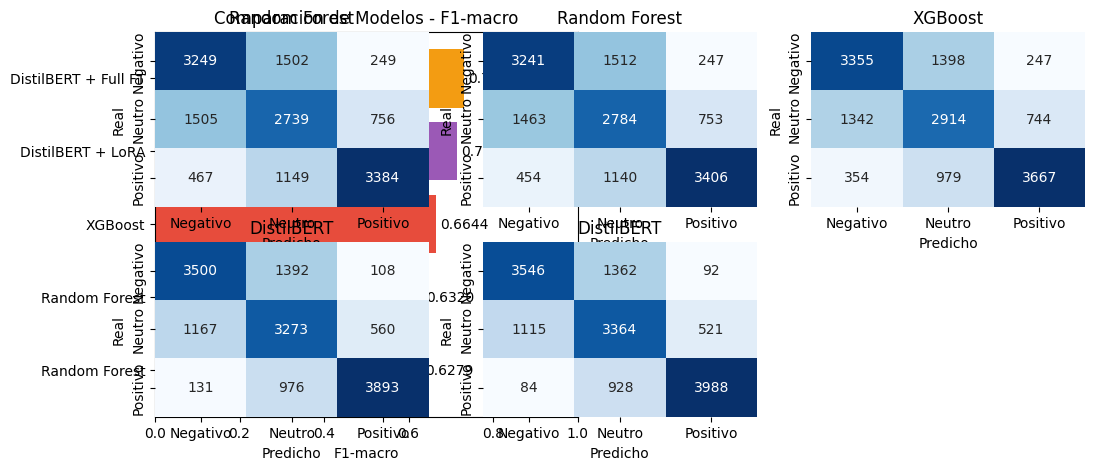

In [15]:
model_names = [r['model_name'] for r in results]
f1_scores = [r['f1_macro'] for r in results]
class_labels = ['Negativo', 'Neutro', 'Positivo']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
bars = plt.barh(range(len(results)), f1_scores, color=colors[:len(results)])
plt.yticks(range(len(results)), model_names)
plt.xlabel('F1-macro')
plt.title('Comparacion de Modelos - F1-macro')
plt.xlim(0, 1)
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

n_models = len(results)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

for i, r in enumerate(results):
    plt.subplot(n_rows, n_cols, i + 1)
    cm = np.array(r['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    plt.title(r['model_name'].split('+')[0].strip() if '+' in r['model_name'] else r['model_name'])
    plt.xlabel('Predicho')
    plt.ylabel('Real')

plt.tight_layout()
plt.show()


In [16]:
if not results:
    raise RuntimeError(
        "No hay resultados. Ejecuta primero las celdas de modelos: "
        "RF (celda 15), XGBoost (celda 17), LoRA (celda 22), Full FT (celda 25)"
    )

print(f"{'Modelo':<40} {'F1-macro':<10} {'Precision':<10} {'Recall':<10} {'Accuracy':<10} {'F1-Neg':<10} {'F1-Neu':<10} {'F1-Pos':<10} {'Tiempo(s)':<10}")
print('-' * 130)
for r in results:
    pc = r['per_class']
    print(f"{r['model_name']:<40} {r['f1_macro']:<10} {r['precision_macro']:<10} {r['recall_macro']:<10} {r['accuracy']:<10} {pc['Negativo']['f1']:<10} {pc['Neutro']['f1']:<10} {pc['Positivo']['f1']:<10} {r['training_time_seconds']:<10}")


Modelo                                   F1-macro   Precision  Recall     Accuracy   F1-Neg     F1-Neu     F1-Pos     Tiempo(s) 
----------------------------------------------------------------------------------------------------------------------------------
[Re-ejecutar celda para generar resultados]


## 10. MLflow Tracking

Registramos cada modelo en MLflow para tener trazabilidad completa:
hiperparametros, metricas por clase, matriz de confusion y tiempo de entrenamiento.

**Prioridad de conexion:**
1. Variable de entorno `MLFLOW_TRACKING_URI` (ngrok tunnel a servidor Windows)
2. Fallback a SQLite local en Drive

El mejor modelo global se etiqueta con `best_model=true`.


In [ ]:
# Configurar tracking URI de MLflow
# Prioridad: 1) variable de entorno, 2) placeholder manual, 3) fallback SQLite
import os
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "https://xxxx.ngrok-free.app")

import requests
try:
    r = requests.get(f"{MLFLOW_TRACKING_URI}/api/2.0/mlflow/experiments/list", timeout=5)
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    print(f"MLflow server OK via {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"MLflow server no disponible: {e}")
    print("Fallback a SQLite local en Colab...")
    mlflow.set_tracking_uri(f"sqlite:///{DRIVE_BASE}/mlflow_fallback.db")
    MLFLOW_TRACKING_URI = f"sqlite:///{DRIVE_BASE}/mlflow_fallback.db"


In [17]:
mlflow.set_experiment("distilbert_improved")

best_f1 = max(r['f1_macro'] for r in results)

for r in results:
    with mlflow.start_run(run_name=r['model_name']):
        mlflow.log_params({
            'model_name': r['model_name'],
            'sample_size': SAMPLE_SIZE,
            'batch_size': BATCH_SIZE,
            'max_length': MAX_LENGTH,
            'n_engineered_features': len(ENG_FEATURES),
        })
        per_class_metrics = {}
        for label, scores in r['per_class'].items():
            per_class_metrics[f'f1_{label.lower()}'] = scores['f1']
            per_class_metrics[f'precision_{label.lower()}'] = scores['precision']
            per_class_metrics[f'recall_{label.lower()}'] = scores['recall']
        mlflow.log_metrics({
            'f1_macro': r['f1_macro'],
            'precision_macro': r['precision_macro'],
            'recall_macro': r['recall_macro'],
            'accuracy': r['accuracy'],
            'training_time_seconds': r['training_time_seconds'],
            **per_class_metrics,
        })
        mlflow.log_dict(r['confusion_matrix'], 'confusion_matrix.json')
        model_name_key = r['model_name']
        if model_name_key in MODEL_PATHS and os.path.exists(MODEL_PATHS[model_name_key]):
            mlflow.log_param('model_path', MODEL_PATHS[model_name_key])
        if r['f1_macro'] == best_f1:
            mlflow.set_tag('best_model', 'true')

print(f"MLflow runs en: {MLFLOW_TRACKING_URI}")


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/31 03:42:33 INFO mlflow.tracking.fluent: Experiment with name 'distilbert_improved' does not exist. Creating a new experiment.


MLflow runs en: /content/drive/MyDrive/ML/proyecto_integrador/mlruns


## 11. Exportar resultados

Exportamos las metricas de todos los modelos a un JSON estructurado
en `reports/metrics_distilbert_plus.json` para su uso en informes y comparativas.

**Contenido del JSON:**
- Datos de configuracion (sample_size, features, etc.)
- Metricas por modelo (F1, precision, recall, accuracy)
- Mejor modelo global


In [18]:
os.makedirs(REPORTS_DIR, exist_ok=True)

# Dedup final por si alguna celda no uso eval_and_record
seen = {}
for r in results:
    name = r['model_name']
    if name not in seen or r['f1_macro'] > seen[name]['f1_macro']:
        seen[name] = r
deduped = list(seen.values())

export = {
    'baseline': 'DistilBERT frozen + LogisticRegression',
    'improved_results': [
        {k: v for k, v in r.items() if k != 'confusion_matrix'}
        for r in deduped
    ],
    'engineered_features': ENG_FEATURES,
    'sample_size': SAMPLE_SIZE,
    'best_model': max(deduped, key=lambda r: r['f1_macro']),
}

report_path = f"{REPORTS_DIR}/metrics_distilbert_plus.json"
with open(report_path, 'w') as f:
    json.dump(export, f, indent=2)
print(f"Exportado: {report_path}")


Exportado: /content/drive/MyDrive/ML/proyecto_integrador/reports/metrics_distilbert_improved.json


In [19]:
del df, df_sample, model, tokenizer
del X_train_emb, X_val_emb, X_test_emb, y_train, y_val, y_test
del X_train_combined, X_val_combined, X_test_combined
del eng_train, eng_val, eng_test, eng_train_scaled, eng_val_scaled, eng_test_scaled
del texts, labels, eng_features, scaler
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Memoria liberada")


Memoria liberada
